In [2]:
import math
import numpy as np
import torch
import random
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import json

import matplotlib.pyplot as plt

In [3]:
device = torch.device('cuda:0')

In [9]:
TEXT_PATH = "/kaggle/input/datasets/vashisht/cka-dataset/enwik88.txt"  



with open(TEXT_PATH) as f:
    text = f.read()

random.seed(0)
STEPS = 128
N_CHARS = 1024
steps = min(STEPS, len(text) // N_CHARS)
start_idxs = random.sample(list(range(len(text) // N_CHARS)), steps)

def get_embeddings(model, tokenizer, start_idxs=start_idxs):
    layer2embs = {}
    n_chars = N_CHARS
    with torch.no_grad():
        emb_layer = model.get_input_embeddings()
        for j in tqdm(start_idxs, desc='Collecting embeddings'):
            j = j * n_chars
            tokens = tokenizer(text[j :j+n_chars], return_tensors="pt").to(device)['input_ids']
            outputs = model(tokens, output_hidden_states=True)
            hidden_states = outputs.hidden_states
            for i, emb in enumerate(hidden_states):
                if i in layer2embs:
                    layer2embs[i] += list(emb.cpu().detach()[0])
                else:
                    layer2embs[i] = list(emb.cpu().detach()[0])
        for i in range(len(hidden_states)):
            layer2embs[i] = torch.stack(layer2embs[i])
        return layer2embs

In [26]:
def get_est_svd(X, Y):
    """
    X -- torch tensor with shape [n_samples, dim]
    Y -- torch tensor with shape [n_samples, dim]

    Approximates Y matrix with linear transformation Y = XA
    """

            
    X = X.float()
    Y = Y.float()

    
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    A_estimation = Vh.T * (1 / S)[None, ...] @ U.T @ Y # Y=XA
    Y_est =  X @ A_estimation
    return Y_est

def procrustes_similarity(x, y):
    """
    x -- torch tensor with shape [n_samples, dim]
    y -- torch tensor with shape [n_samples, dim]
    """
    
    with torch.no_grad():
        
        X = x - x.mean(dim=0, keepdim=True)
        Y = y - y.mean(dim=0, keepdim=True)
    
        X = X / X.norm()
        Y = Y / Y.norm()
    
        Y_estimation = get_est_svd(X, Y)
    
        y_error = (Y_estimation - Y).square().sum()
        sim = float(1 - y_error)
    return sim

def procrustes_similarity_centered(x, y0):
    """
    x -- torch tensor with shape [n_samples, dim]
    y -- torch tensor with shape [n_samples, dim]
    """
    with torch.no_grad():
        y = y0 - x
        
        X = x - x.mean(dim=0, keepdim=True)
        Y = y - y.mean(dim=0, keepdim=True)
    
        X = X / X.norm()
        Y = Y / Y.norm()
    
        Y_estimation = get_est_svd(X, Y)
    
        y_error = (Y_estimation - Y).square().sum()
        sim = float(1 - y_error)
    return sim


# def cka_similarity(x, y, eps=1e-8):
#     """
#     Computes linear CKA similarity between two matrices.

#     x -- torch tensor with shape [n_samples, dim_x]
#     y -- torch tensor with shape [n_samples, dim_y]

#     Returns:
#         float CKA similarity in [0, 1] approximately
#     """

#     with torch.no_grad():
#         # Use float32 because fp16 can break linear algebra/norm operations
#         X = x.float()
#         Y = y.float()

#         # Linear CKA:
#         # ||X^T Y||_F^2 / (||X^T X||_F * ||Y^T Y||_F)
#         XT_Y = X.T @ Y
#         XT_X = X.T @ X
#         YT_Y = Y.T @ Y

#         numerator = (XT_Y ** 2).sum()
#         denominator = torch.sqrt((XT_X ** 2).sum() * (YT_Y ** 2).sum())

#         cka = numerator / (denominator + eps)

#     return float(cka)

def cka_similarity_centered(x, y, eps=1e-8):
    """
    Computes linear CKA similarity between two matrices.

    x -- torch tensor with shape [n_samples, dim_x]
    y -- torch tensor with shape [n_samples, dim_y]

    Returns:
        float CKA similarity in [0, 1] approximately
    """

    with torch.no_grad():
        # Use float32 because fp16 can break linear algebra/norm operations
        X = x.double()
        Y = y.double()

        # Center features across samples
        X = X - X.mean(dim=0, keepdim=True)
        Y = Y - Y.mean(dim=0, keepdim=True)

        # Linear CKA:
        # ||X^T Y||_F^2 / (||X^T X||_F * ||Y^T Y||_F)
        XT_Y = X.T @ Y
        XT_X = X.T @ X
        YT_Y = Y.T @ Y

        numerator = (XT_Y ** 2).sum()
        denom_x = torch.sqrt((XT_X ** 2).sum())
        denom_y = torch.sqrt((YT_Y ** 2).sum())

        cka = numerator / (denom_x * denom_y + eps)

        # numerator = (XT_Y ** 2).sum()
        # denominator = torch.sqrt((XT_X ** 2).sum() * (YT_Y ** 2).sum())

        # cka = numerator / (denominator + eps)

    return float(cka)


def update_norm_ratios(x,y,eps=1e-8):
    """
    Compute ||y - x|| / ||x|| for two consecutive layer representations.

    Args:
        x: layer l representation, shape [n_samples, dim]
        y: layer l+1 representation, shape [n_samples, dim]
        eps: numerical stability constant
    Returns:
        scalar float
    """
    x = x.float()
    y = y.float()

    delta = y - x

    ratio = torch.linalg.vector_norm(delta) / (torch.linalg.vector_norm(x) + eps)
    return ratio.item()

def get_est_svd(X, Y, eps=1e-8):
    """
    Approximate Y with linear transformation Y = X A.
    X: [n_samples, dim]
    Y: [n_samples, dim]
    """
    X = X.float()
    Y = Y.float()

    U, S, Vh = torch.linalg.svd(X, full_matrices=False)

    S_inv = 1.0 / (S + eps)
    A_estimation = (Vh.T * S_inv[None, :]) @ U.T @ Y

    Y_est = X @ A_estimation
    return Y_est


def procrustes_similarity(x, y, eps=1e-8):
    """
    Procrustes-style similarity between x and y.
    """
    with torch.no_grad():
        X = x.float()
        Y = y.float()

        X = X - X.mean(dim=0, keepdim=True)
        Y = Y - Y.mean(dim=0, keepdim=True)

        X = X / (X.norm() + eps)
        Y = Y / (Y.norm() + eps)

        Y_est = get_est_svd(X, Y, eps=eps)

        y_error = (Y_est - Y).square().sum()
        sim = 1.0 - y_error

    return float(sim)

In [27]:
model_names = [
    #"facebook/opt-125m",
    #"TheBloke/Llama-2-7B-fp16",
    "gpt2",
    "gpt2-medium",
    "gpt2-large",
    "gpt2-xl",
]

In [28]:
all_results = {
    'procrustes_similarity': {},
#    'cka_similarity':{},
    'cka_similarity_centered':{},
    'update_norm_ratio':{}
#    'procrustes_similarity_centered': {},
#    'intrinsic_dimension': {},
#    'anisotropy': {}
}

save_path = './results.json'
with torch.no_grad():
    for model_name in model_names:
        
        torch.cuda.empty_cache()
        print(f'Starting tests for model {model_name}')
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
        model.eval()
        embs_dict = get_embeddings(model, tokenizer, start_idxs=start_idxs)
        print('Embs shape: ', embs_dict[0].shape)

        similarities = []
        for layer in tqdm(range(max(embs_dict.keys()) - 1), desc=f'{model_name} procrustes_similarity'):
            similarities.append(procrustes_similarity(embs_dict[layer], embs_dict[layer+1]))
            all_results['procrustes_similarity'][model_name] = similarities


        # similarities = []
        # for layer in tqdm(range(max(embs_dict.keys()) - 1), desc=f'{model_name} cka_similarity'):
        #     similarities.append(cka_similarity(embs_dict[layer], embs_dict[layer+1]))
        #     all_results['cka_similarity'][model_name] = similarities

        similarities = []
        for layer in tqdm(range(max(embs_dict.keys()) -1 ), desc= f'{model_name} cka_similarity_centered'):
            similarities.append(cka_similarity_centered(embs_dict[layer],embs_dict[layer+1]))
            all_results['cka_similarity_centered'][model_name] = similarities

        norm_ratios = []
        for layer in tqdm(range(max(embs_dict.keys())-1),desc=f'{model_name} norm_ratios'):
            norm_ratios.append(update_norm_ratios(embs_dict[layer],embs_dict[layer+1]))
            all_results['update_norm_ratio'][model_name] = norm_ratios
        #similarities = []
        #for layer in tqdm(range(max(embs_dict.keys()) - 1), desc=f'{model_name} procrustes_similarity_centered'):
        #    similarities.append(procrustes_similarity_centered(embs_dict[layer], embs_dict[layer+1]))
        #all_results['procrustes_similarity_centered'][model_name] = similarities

        # with open(save_path, 'w') as outfile:
        #     json.dump(all_results, outfile)

Starting tests for model gpt2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embs shape:  torch.Size([27228, 768])


gpt2 norm_ratios: 100%|██████████| 11/11 [00:00<00:00, 39.82it/s]


...

Starting tests for model gpt2-xl


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embs shape:  torch.Size([27228, 1600])


gpt2-xl norm_ratios: 100%|██████████| 47/47 [00:02<00:00, 18.70it/s]


In [29]:
all_results                                   

{'procrustes_similarity': {'gpt2': [0.8746516108512878,
   0.9724883437156677,
   0.9960170984268188,
   0.9956129789352417,
   0.9958140254020691,
   0.9941092729568481,
   0.9932233691215515,
   0.9904055595397949,
   0.9882296919822693,
   0.9827127456665039,
   0.9751815795898438],
  'gpt2-medium': [0.8760049343109131,
   0.9516739845275879,
   0.9580860733985901,
   0.995594322681427,
   0.9957288503646851,
   0.995614230632782,
   0.9951802492141724,
   0.9946156144142151,
   0.9948103427886963,
   0.9937001466751099,
   0.9934912919998169,
   0.9929119944572449,
   0.9925658702850342,
   0.9919963479042053,
   0.9907037019729614,
   0.9898666739463806,
   0.9892295002937317,
   0.9883063435554504,
   0.9869939684867859,
   0.985420823097229,
   0.9846326112747192,
   0.9806217551231384,
   0.9715291261672974],
  'gpt2-large': [0.8014860153198242,
   0.9037626385688782,
   0.941368043422699,
   0.9531223177909851,
   0.958048403263092,
   0.9606337547302246,
   0.9636785984039307

In [18]:
all_results                                   

{'procrustes_similarity': {'facebook/opt-125m': [0.9880707263946533,
   0.9983029365539551,
   0.9993978142738342,
   0.9995589852333069,
   0.9993413090705872,
   0.9990553259849548,
   0.9988077282905579,
   0.9984169602394104,
   0.9972264170646667,
   0.9950006008148193,
   0.9931874871253967],
  'TheBloke/Llama-2-7B-fp16': [0.9167525172233582,
   0.9907768368721008,
   0.9999493956565857,
   0.9999100565910339,
   0.9998391270637512,
   0.9997695088386536,
   0.9996989965438843,
   0.9995967149734497,
   0.9994873404502869,
   0.9993916153907776,
   0.9993069767951965,
   0.999274492263794,
   0.9991520643234253,
   0.9989864230155945,
   0.9987694621086121,
   0.9984263777732849,
   0.9978472590446472,
   0.9978125691413879,
   0.9973804354667664,
   0.9970877170562744,
   0.9964953660964966,
   0.996399462223053,
   0.9958992004394531,
   0.9957384467124939,
   0.9954153299331665,
   0.9952458143234253,
   0.994541585445404,
   0.9941166043281555,
   0.993309497833252,
   0.9924

In [39]:
all_results['procrustes_similarity']["facebook/opt-125m"] = [0.9880707263946533,
   0.9983029365539551,
   0.9993978142738342,
   0.9995589852333069,
   0.9993413090705872,
   0.9990553259849548,
   0.9988077282905579,
   0.9984169602394104,
   0.9972264170646667,
   0.9950006008148193,
   0.9931874871253967]

In [40]:
all_results['procrustes_similarity']["TheBloke/Llama-2-7B-fp16"] = [0.9167525172233582,
   0.9907768368721008,
   0.9999493956565857,
   0.9999100565910339,
   0.9998391270637512,
   0.9997695088386536,
   0.9996989965438843,
   0.9995967149734497,
   0.9994873404502869,
   0.9993916153907776,
   0.9993069767951965,
   0.999274492263794,
   0.9991520643234253,
   0.9989864230155945,
   0.9987694621086121,
   0.9984263777732849,
   0.9978472590446472,
   0.9978125691413879,
   0.9973804354667664,
   0.9970877170562744,
   0.9964953660964966,
   0.996399462223053,
   0.9958992004394531,
   0.9957384467124939,
   0.9954153299331665,
   0.9952458143234253,
   0.994541585445404,
   0.9941166043281555,
   0.993309497833252,
   0.9924269914627075,
   0.9652340412139893]

In [41]:
all_results['cka_similarity_centered']["facebook/opt-125m"] = [0.08475950360298157,
   0.9999847412109375,
   0.9999914765357971,
   0.9999991059303284,
   0.9999993443489075,
   0.9999986886978149,
   0.9999988675117493,
   0.9999989867210388,
   0.9999982118606567,
   0.9999958872795105,
   0.9999921321868896]

In [42]:
all_results['cka_similarity_centered']["TheBloke/Llama-2-7B-fp16"] = [0.4967958331108093,
   0.19291168451309204,
   0.9999987483024597,
   0.9999998807907104,
   0.9999973177909851,
   0.9999998211860657,
   0.9999995231628418,
   0.9999996423721313,
   0.9999997019767761,
   0.9999991655349731,
   0.9999996423721313,
   0.9999996423721313,
   0.9999990463256836,
   0.9999985694885254,
   0.9999989867210388,
   0.9999987483024597,
   0.9999985098838806,
   0.9999977350234985,
   0.9999964237213135,
   0.9999971985816956,
   0.9999951720237732,
   0.9999944567680359,
   0.9999937415122986,
   0.9999969005584717,
   0.9999918937683105,
   0.9999961256980896,
   0.9999914765357971,
   0.9999950528144836,
   0.9999881386756897,
   0.9999662637710571,
   0.24584385752677917]

In [ ]:
all_results['update_norm_ratio']["facebook/opt-125m"] =  [5.017489433288574,
   0.43530386686325073,
   0.796367883682251,
   0.10166263580322266,
   0.09729578346014023,
   0.04012450575828552,
   0.045643534511327744,
   0.05274800583720207,
   0.07219941169023514,
   0.10399936139583588,
   0.1202421709895134]

In [43]:
all_results['update_norm_ratio']["TheBloke/Llama-2-7B-fp16"] = [1.7685356140136719,
   107.4103012084961,
   0.011011907830834389,
   0.014204294420778751,
   0.020319655537605286,
   0.02197903022170067,
   0.024770192801952362,
   0.028815502300858498,
   0.032299358397722244,
   0.03485964983701706,
   0.037846989929676056,
   0.038829538971185684,
   0.04165208339691162,
   0.04717488959431648,
   0.05016019940376282,
   0.05776970833539963,
   0.06989652663469315,
   0.0690888985991478,
   0.0748278871178627,
   0.07867161929607391,
   0.09055548161268234,
   0.0888342559337616,
   0.09811795502901077,
   0.09201609343290329,
   0.10041078925132751,
   0.09867262095212936,
   0.11225422471761703,
   0.1088307648897171,
   0.12639088928699493,
   0.14341627061367035,
   0.8404021263122559]

# Plotting Results for Pretrained Model

In [59]:
# all_results should contain:
# all_results["procrustes_similarity"]
# all_results["cka_similarity_centered"]
# all_results["update_norm_ratio"]

name_map = {
    "facebook/opt-125m": "OPT-125M",
    "TheBloke/Llama-2-7B-fp16": "Llama-2-7B",
    "gpt2": "GPT-2",
    "gpt2-medium": "GPT-2 Medium",
    "gpt2-large": "GPT-2 Large",
    "gpt2-xl": "GPT-2 XL",
}

model_order = [
    "OPT-125M",
    "GPT-2",
    "GPT-2 Medium",
    "GPT-2 Large",
    "GPT-2 XL",
    "Llama-2-7B",
]

def rename_results(results, name_map):
    renamed = {}
    for metric, model_dict in results.items():
        renamed[metric] = {}
        for model_name, values in model_dict.items():
            new_name = name_map.get(model_name, model_name)
            renamed[metric][new_name] = values
    return renamed

plot_results = rename_results(all_results, name_map)

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def bold_ticks(ax):
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

def normalized_depth(n):
    if n == 1:
        return np.array([0.0])
    return np.arange(n) / (n - 1)

def plot_metric(
    results,
    metric_key,
    ylabel,
    output_pdf,
    exclude_first=False,
    ylim=None,
    yscale=None,
    legend_loc="best",
):
    metric_dict = results[metric_key]

    fig, ax = plt.subplots(figsize=(10.5, 7.0))

    for model_name in model_order:
        if model_name not in metric_dict:
            continue

        values = np.array(metric_dict[model_name], dtype=float)

        if exclude_first:
            values = values[2:]

        x = normalized_depth(len(values))

        ax.plot(
            x,
            values,
            marker="o",
            linewidth=2.8,
            markersize=6.5,
            label=model_name,
        )

    ax.set_xlabel("Normalized depth", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")

    ax.set_xlim(-0.02, 1.02)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if yscale is not None:
        ax.set_yscale(yscale)

    ax.grid(True, alpha=0.3, which="both")
    ax.legend(frameon=False, loc=legend_loc, ncol=1)
    bold_ticks(ax)

    plt.tight_layout()
    plt.savefig(output_pdf, bbox_inches="tight")
    plt.show()

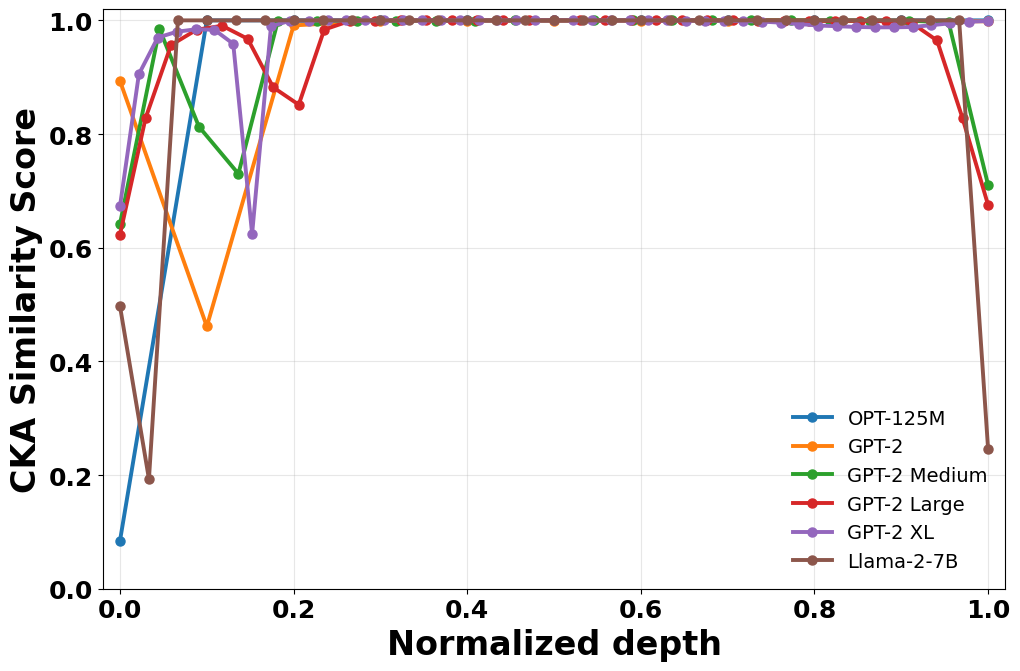

In [56]:
plot_metric(
    results=plot_results,
    metric_key="cka_similarity_centered",
    ylabel="CKA Similarity Score",
    output_pdf="pretrained_centered_cka.pdf",
    exclude_first=False,
    ylim=(0.0, 1.02),
    legend_loc="lower right",
)

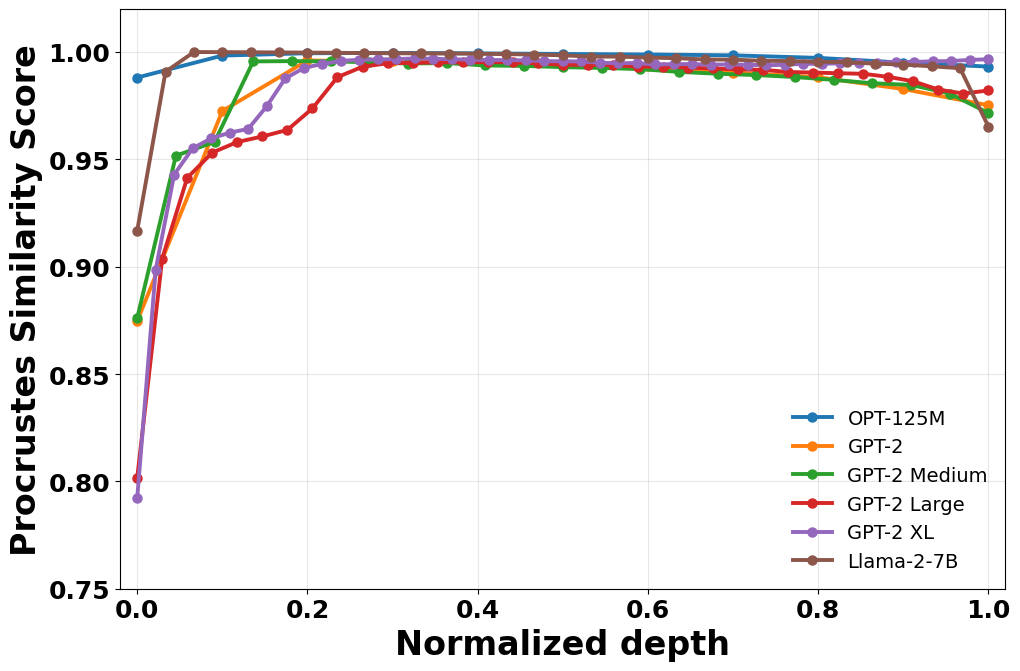

In [57]:
plot_metric(
    results=plot_results,
    metric_key="procrustes_similarity",
    ylabel="Procrustes Similarity Score",
    output_pdf="pretrained_procrustes.pdf",
    exclude_first=False,
    ylim=(0.75, 1.02),
    legend_loc="lower right",
)

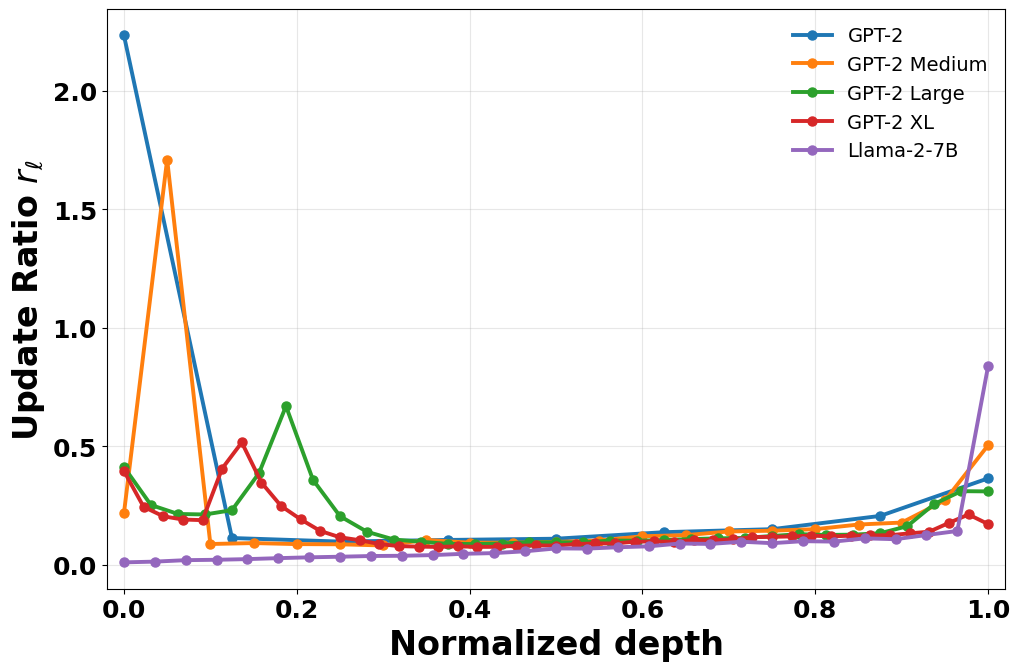

In [60]:
plot_metric(
    results=plot_results,
    metric_key="update_norm_ratio",
    ylabel=r"Update Ratio $r_\ell$",
    output_pdf="pretrained_update_norm.pdf",
    exclude_first=True,
    ylim=None,
    legend_loc="upper right",
)